# Exploratory Data Analysis

Performing Esports Analytics on League of Legends matches. The data contains the korean challanger players ranked matches.

**Origin of the data:** https://developer.riotgames.com

# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# Importing the data

In [2]:
eda_df = pd.read_csv("event_driven_eda_sample.csv")

C:\Users\Balázs\AppData\Local\Temp\ipykernel_4984\2688481024.py:1: DtypeWarning: Columns (0: monsterType, 1: monsterSubType) have mixed types. Specify dtype option on import or set low_memory=False.
  eda_df = pd.read_csv("event_driven_eda_sample.csv")


# Initial data exploration

In [3]:
eda_df.head()

,matchId,minute,realTimestamp,timestamp,type,itemId,participantId,levelUpType,skillSlot,creatorId,...,kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_t100,cum_kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_diff,kill_true_dmg_received_t100,kill_true_dmg_received_t200,cum_kill_true_dmg_received_t100,cum_kill_true_dmg_received_t200,cum_kill_true_dmg_received_diff,target_win_t100
0,KR_8031700522,1,NaN,256,WARD_PLACED,NaN,NaN,NaN,NaN,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,KR_8031700522,1,NaN,256,WARD_PLACED,NaN,NaN,NaN,NaN,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,KR_8031700522,1,NaN,2060,ITEM_PURCHASED,2003.0,9.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,KR_8031700522,1,NaN,2060,ITEM_PURCHASED,1055.0,9.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,KR_8031700522,1,NaN,2361,ITEM_PURCHASED,1056.0,3.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
eda_df.tail()

,matchId,minute,realTimestamp,timestamp,type,itemId,participantId,levelUpType,skillSlot,creatorId,...,kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_t100,cum_kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_diff,kill_true_dmg_received_t100,kill_true_dmg_received_t200,cum_kill_true_dmg_received_t100,cum_kill_true_dmg_received_t200,cum_kill_true_dmg_received_diff,target_win_t100
2659251,KR_8127863330,19,NaN,1086414,WARD_KILL,NaN,NaN,NaN,NaN,NaN,...,0.0,21437.0,4416.0,17021.0,0.0,0.0,1658.0,227.0,1431.0,1
2659252,KR_8127863330,19,NaN,1086914,LEVEL_UP,NaN,6.0,NaN,NaN,NaN,...,0.0,21437.0,4416.0,17021.0,0.0,0.0,1658.0,227.0,1431.0,1
2659253,KR_8127863330,19,NaN,1087148,WARD_PLACED,NaN,NaN,NaN,NaN,2.0,...,0.0,21437.0,4416.0,17021.0,0.0,0.0,1658.0,227.0,1431.0,1
2659254,KR_8127863330,19,NaN,1091891,SKILL_LEVEL_UP,NaN,6.0,NORMAL,3.0,NaN,...,0.0,21437.0,4416.0,17021.0,0.0,0.0,1658.0,227.0,1431.0,1
2659255,KR_8127863330,19,NaN,1092114,WARD_PLACED,NaN,NaN,NaN,NaN,4.0,...,0.0,21437.0,4416.0,17021.0,0.0,0.0,1658.0,227.0,1431.0,1


In [5]:
eda_df.shape # Shape of the dataset (rows, columns)

(2659256, 704)

672 features, 66k rows

In [6]:
eda_df.info() # Summary of the dataset, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 2659256 entries, 0 to 2659255
Columns: 704 entries, matchId to target_win_t100
dtypes: float64(640), int64(53), str(11)
memory usage: 13.9 GB


In [7]:
eda_df.columns # List of column names in the dataset

Index(['matchId', 'minute', 'realTimestamp', 'timestamp', 'type', 'itemId',
       'participantId', 'levelUpType', 'skillSlot', 'creatorId',
       ...
       'kill_magic_dmg_received_t200', 'cum_kill_magic_dmg_received_t100',
       'cum_kill_magic_dmg_received_t200', 'cum_kill_magic_dmg_received_diff',
       'kill_true_dmg_received_t100', 'kill_true_dmg_received_t200',
       'cum_kill_true_dmg_received_t100', 'cum_kill_true_dmg_received_t200',
       'cum_kill_true_dmg_received_diff', 'target_win_t100'],
      dtype='str', length=704)

## Explanation of the columns:
* 'match_id': Unique identifier for each match.
* 'minute': The minute of the match when the event occurred.
* 'timestamp': The exact time when the event occurred.
* '*_p(1-10)': Player-specific statistics for each of the 10 players in the match, such as kills, deaths, assists, gold earned, etc.
* 'cum*_*': Cumulative statistics for each team up to that minute, such as cumulative kills, deaths, assists, gold earned, etc.
* '*diff': The difference in a specific statistic between the two teams at that minute, such as gold difference, kill difference, etc.
* 'target_win_t100': Target variable indicating whether team won the game


In [8]:
eda_df['matchId'].unique() # Unique values in the dataset

<StringArray>
['KR_8031700522', 'KR_8031786686', 'KR_8033124346', 'KR_8035806533',
 'KR_8036705617', 'KR_8037046690', 'KR_8037590215', 'KR_8038460687',
 'KR_8038872374', 'KR_8041032915',
 ...
 'KR_8126932260', 'KR_8126953234', 'KR_8127074850', 'KR_8127142412',
 'KR_8127206496', 'KR_8127336116', 'KR_8127425521', 'KR_8127487680',
 'KR_8127543182', 'KR_8127863330']
Length: 2475, dtype: str

2475 unique matches

In [9]:
eda_df.describe() # Statistical summary of numerical columns

,minute,realTimestamp,timestamp,itemId,participantId,skillSlot,creatorId,level,killerId,positionX,...,kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_t100,cum_kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_diff,kill_true_dmg_received_t100,kill_true_dmg_received_t200,cum_kill_true_dmg_received_t100,cum_kill_true_dmg_received_t200,cum_kill_true_dmg_received_diff,target_win_t100
count,2.659256e+06,0.0,2.659256e+06,1.125726e+06,1.794795e+06,350503.000000,489528.000000,318566.000000,374933.000000,252127.000000,...,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06,2.659256e+06
mean,1.442262e+01,NaN,8.351916e+05,2.150275e+03,5.513421e+00,2.240700,5.957831,8.298120,5.402067,7761.932304,...,1.751546e+01,6.976299e+03,6.837403e+03,1.388959e+02,2.759547e+00,2.764227e+00,9.910551e+02,9.924341e+02,-1.378932e+00,5.262476e-01
std,8.456264e+00,NaN,5.079676e+05,2.334126e+03,2.867790e+00,1.070503,2.945762,4.220151,2.849007,3807.656560,...,1.531204e+02,8.484200e+03,8.294036e+03,6.210413e+03,3.638390e+01,3.659358e+01,1.489363e+03,1.479959e+03,1.356351e+03,4.993107e-01
min,1.000000e+00,NaN,2.500000e+02,1.001000e+03,1.000000e+00,1.000000,1.000000,2.000000,1.000000,154.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,-5.697800e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.468500e+04,0.000000e+00
25%,8.000000e+00,NaN,4.288640e+05,1.043000e+03,3.000000e+00,1.000000,4.000000,5.000000,3.000000,4790.000000,...,0.000000e+00,9.780000e+02,9.420000e+02,-1.748000e+03,0.000000e+00,0.000000e+00,9.000000e+01,8.900000e+01,-3.040000e+02,0.000000e+00
50%,1.400000e+01,NaN,8.039575e+05,2.022000e+03,5.000000e+00,2.000000,5.000000,8.000000,5.000000,7943.000000,...,0.000000e+00,3.960000e+03,3.862000e+03,0.000000e+00,0.000000e+00,0.000000e+00,4.460000e+02,4.430000e+02,0.000000e+00,1.000000e+00
75%,2.000000e+01,NaN,1.193794e+06,3.044000e+03,8.000000e+00,3.000000,9.000000,11.000000,8.000000,10504.000000,...,0.000000e+00,9.926000e+03,9.691000e+03,1.948000e+03,0.000000e+00,0.000000e+00,1.281000e+03,1.280000e+03,3.030000e+02,1.000000e+00
max,5.700000e+01,NaN,3.384719e+06,3.280200e+05,1.000000e+01,4.000000,10.000000,24.000000,10.000000,14574.000000,...,8.979000e+03,9.338000e+04,9.697600e+04,6.704500e+04,5.803000e+03,4.118000e+03,2.622400e+04,2.537100e+04,1.788300e+04,1.000000e+00


In [10]:
eda_df[eda_df.duplicated()] # Check for duplicate rows in the dataset

,matchId,minute,realTimestamp,timestamp,type,itemId,participantId,levelUpType,skillSlot,creatorId,...,kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_t100,cum_kill_magic_dmg_received_t200,cum_kill_magic_dmg_received_diff,kill_true_dmg_received_t100,kill_true_dmg_received_t200,cum_kill_true_dmg_received_t100,cum_kill_true_dmg_received_t200,cum_kill_true_dmg_received_diff,target_win_t100


No duplicates.

In [11]:
eda_df.isnull().sum() # Check for missing values in each column

matchId                                  0
minute                                   0
realTimestamp                      2659256
timestamp                                0
type                                     0
                                    ...   
kill_true_dmg_received_t200              0
cum_kill_true_dmg_received_t100          0
cum_kill_true_dmg_received_t200          0
cum_kill_true_dmg_received_diff          0
target_win_t100                          0
Length: 704, dtype: int64

## Visualizations

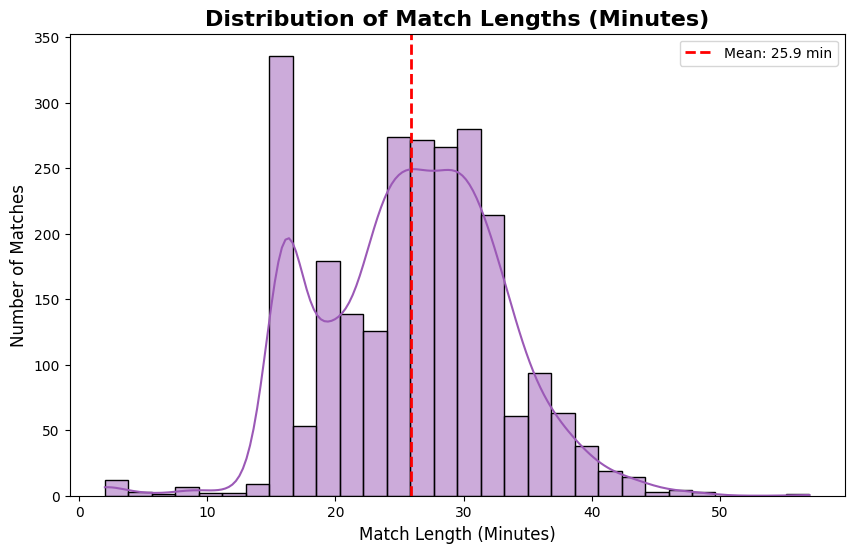

In [12]:
# Get the maximum minute for each match
match_lengths = eda_df.groupby('matchId')['minute'].max()

plt.figure(figsize=(10, 6))
sns.histplot(match_lengths, bins=30, color='#9b59b6', kde=True)

plt.title('Distribution of Match Lengths (Minutes)', fontsize=16, fontweight='bold')
plt.xlabel('Match Length (Minutes)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.axvline(match_lengths.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {match_lengths.mean():.1f} min')
plt.legend()
plt.show()

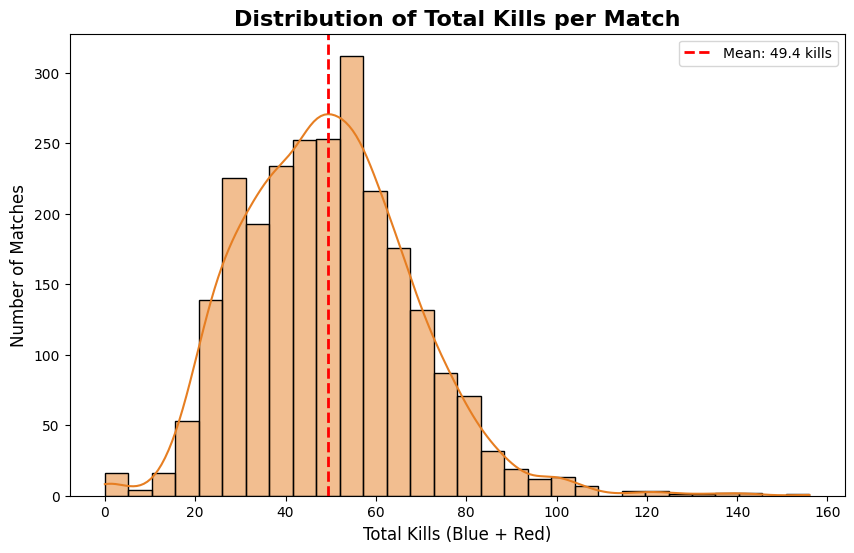

In [13]:
# Get the total kills at the very last minute of each match
# We add Blue (t100) and Red (t200) cumulative kills together
last_minute_df = eda_df.loc[eda_df.groupby('matchId')['minute'].idxmax()]

total_kills = last_minute_df['cum_CHAMPION_KILL_t100'] + last_minute_df['cum_CHAMPION_KILL_t200']
    
plt.figure(figsize=(10, 6))
sns.histplot(total_kills, bins=30, color='#e67e22', kde=True)
    
plt.title('Distribution of Total Kills per Match', fontsize=16, fontweight='bold')
plt.xlabel('Total Kills (Blue + Red)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.axvline(total_kills.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {total_kills.mean():.1f} kills')
plt.legend()
plt.show()

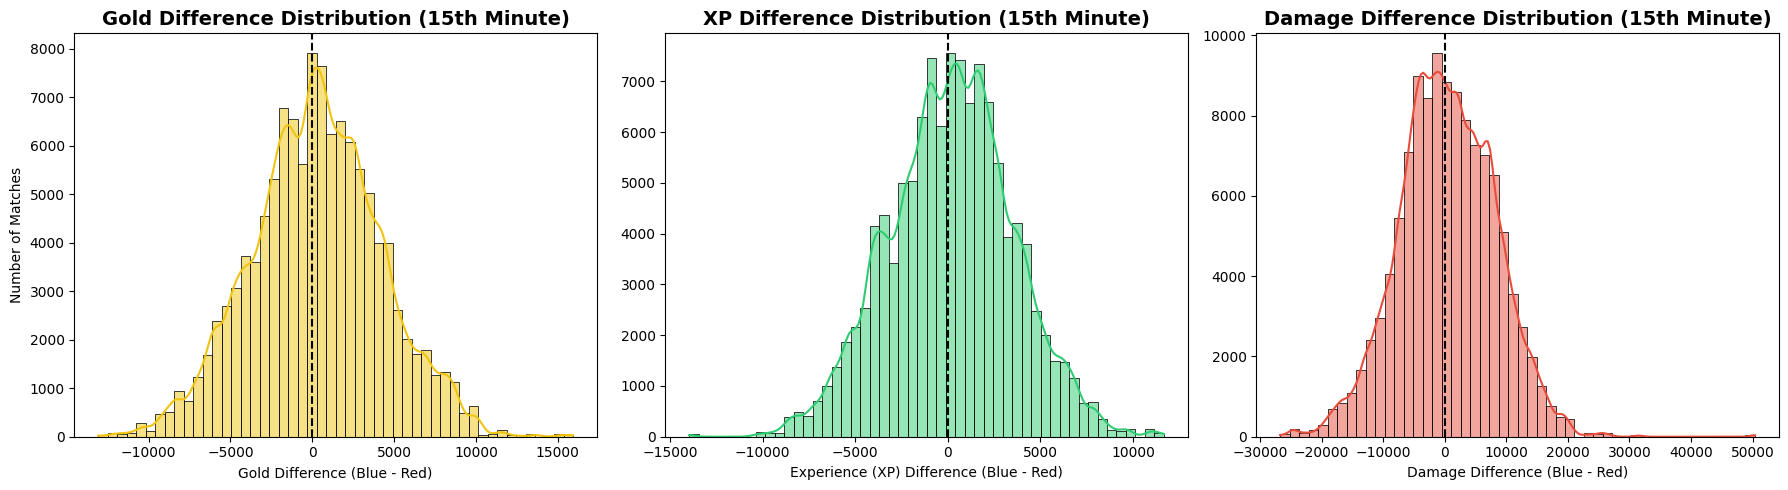

In [14]:
# Filter the dataset for the 15th minute
min15_df = eda_df[eda_df['minute'] == 15].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gold difference distribution
sns.histplot(min15_df['totalGold_diff'], bins=50, ax=axes[0], color='#f1c40f', kde=True)
axes[0].set_title('Gold Difference Distribution (15th Minute)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gold Difference (Blue - Red)')
axes[0].set_ylabel('Number of Matches')
axes[0].axvline(0, color='black', linestyle='--')

# 2. XP difference distribution
sns.histplot(min15_df['xp_diff'], bins=50, ax=axes[1], color='#2ecc71', kde=True)
axes[1].set_title('XP Difference Distribution (15th Minute)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Experience (XP) Difference (Blue - Red)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linestyle='--')

# 3. Damage difference distribution
sns.histplot(min15_df['dmg_totalDamageDoneToChampions_diff'], bins=50, ax=axes[2], color='#e74c3c', kde=True)
axes[2].set_title('Damage Difference Distribution (15th Minute)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Damage Difference (Blue - Red)')
axes[2].set_ylabel('')
axes[2].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

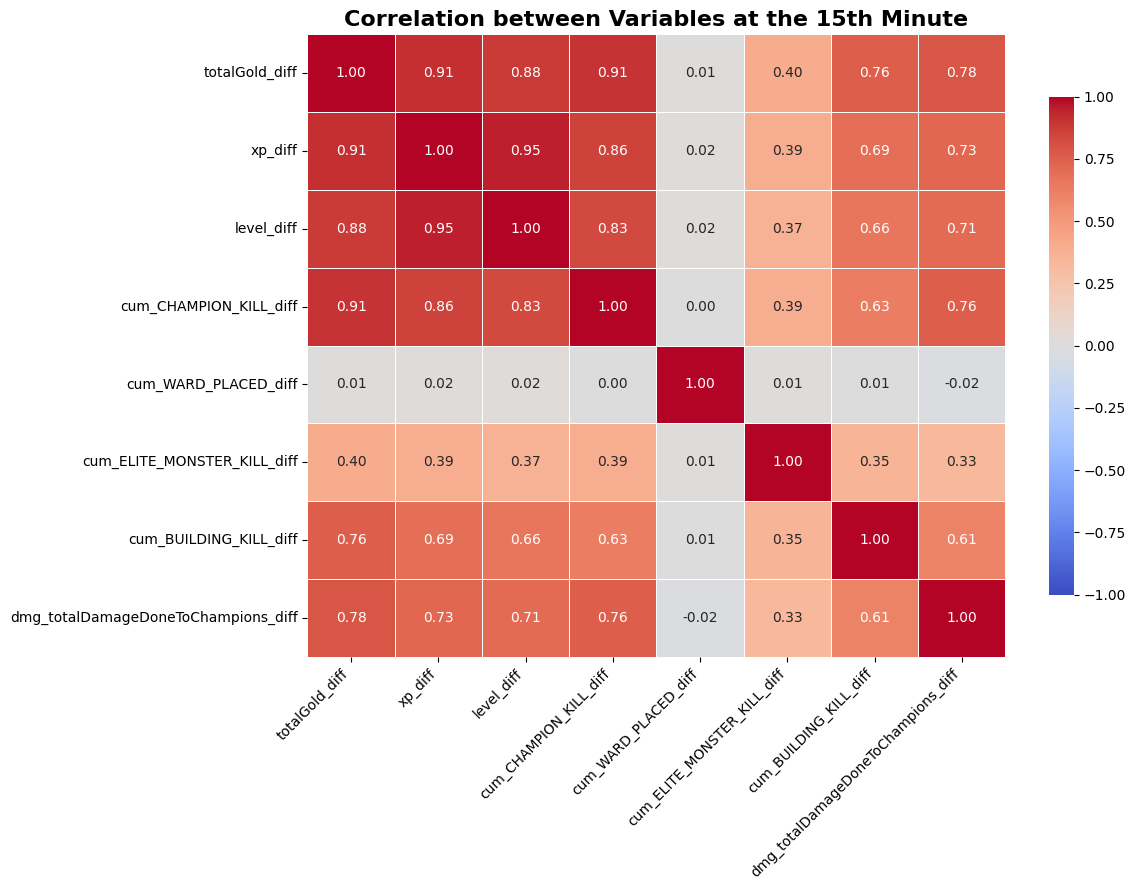

In [15]:
# Most likely to be correlated with the final outcome (win/loss) at the 15th minute:
cols_for_corr = [
    'totalGold_diff', 
    'xp_diff', 
    'level_diff', 
    'cum_CHAMPION_KILL_diff',
    'cum_WARD_PLACED_diff',
    'cum_ELITE_MONSTER_KILL_diff',
    'cum_BUILDING_KILL_diff',
    'dmg_totalDamageDoneToChampions_diff'
]

# Validate that the columns exist in the DataFrame before calculating the correlation matrix
valid_cols = [c for c in cols_for_corr if c in min15_df.columns]

# Calculate the correlation matrix for the valid columns
corr_matrix = min15_df[valid_cols].corr()

# Vizualization of the correlation matrix using a heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, 
            annot=True,          
            cmap='coolwarm',     
            fmt=".2f",           
            vmin=-1, vmax=1,    
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation between Variables at the 15th Minute', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap for kill coordinates

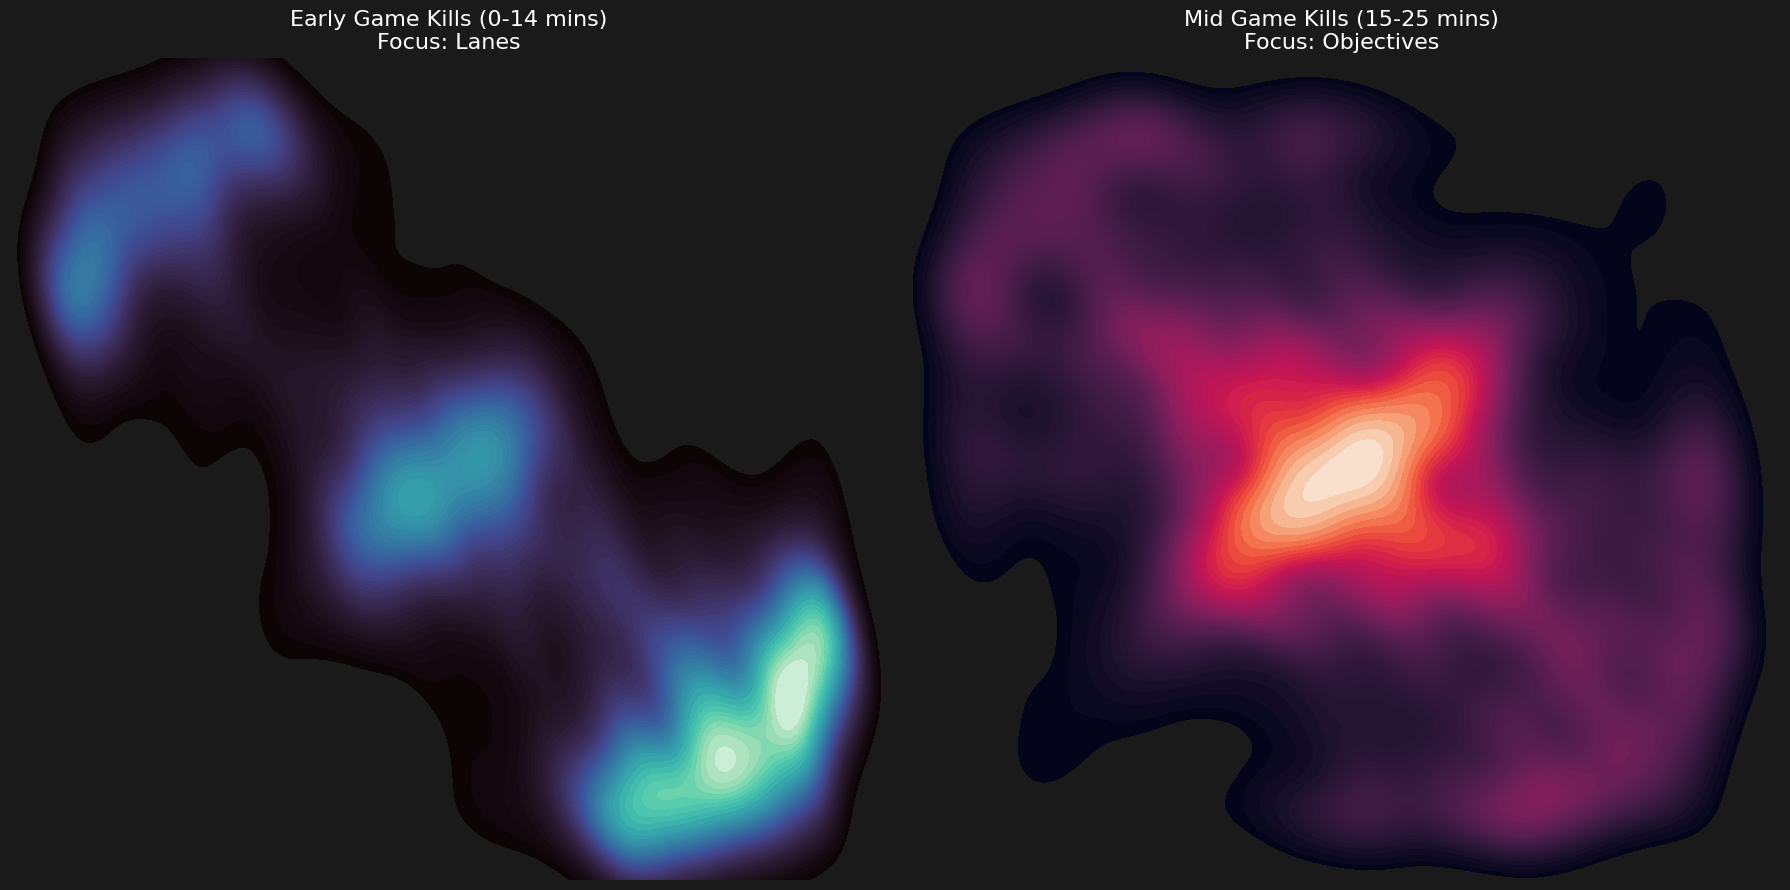

In [20]:
# Filter out only CHAMPION_KILL events with valid coordinates
kills_df = eda_df[(eda_df['type'] == 'CHAMPION_KILL') & (eda_df['positionX'].notna())]

# Separate into Early Game (Laning Phase & Early Ganks) and Mid Game (Objective Fights)
early_kills = kills_df[kills_df['minute'] <= 14]
mid_kills = kills_df[(kills_df['minute'] > 14) & (kills_df['minute'] <= 25)]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#1a1a1a')

# Subplot 1: Early Game Heatmap (0-14 mins)
axes[0].set_facecolor('#1a1a1a')
sns.kdeplot(x=early_kills['positionX'], y=early_kills['positionY'], 
            cmap="mako", fill=True, thresh=0.05, levels=50, ax=axes[0])
axes[0].set_title("Early Game Kills (0-14 mins)\nFocus: Lanes", color='white', fontsize=16)
axes[0].set_xlim(0, 15000)
axes[0].set_ylim(0, 15000)
axes[0].axis('off')

# Subplot 2: Mid Game Heatmap (15-25 mins)
axes[1].set_facecolor('#1a1a1a')
sns.kdeplot(x=mid_kills['positionX'], y=mid_kills['positionY'], 
            cmap="rocket", fill=True, thresh=0.05, levels=50, ax=axes[1])
axes[1].set_title("Mid Game Kills (15-25 mins)\nFocus: Objectives", color='white', fontsize=16)
axes[1].set_xlim(0, 15000)
axes[1].set_ylim(0, 15000)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Gold and XP difference boxplots for Early vs Mid Game

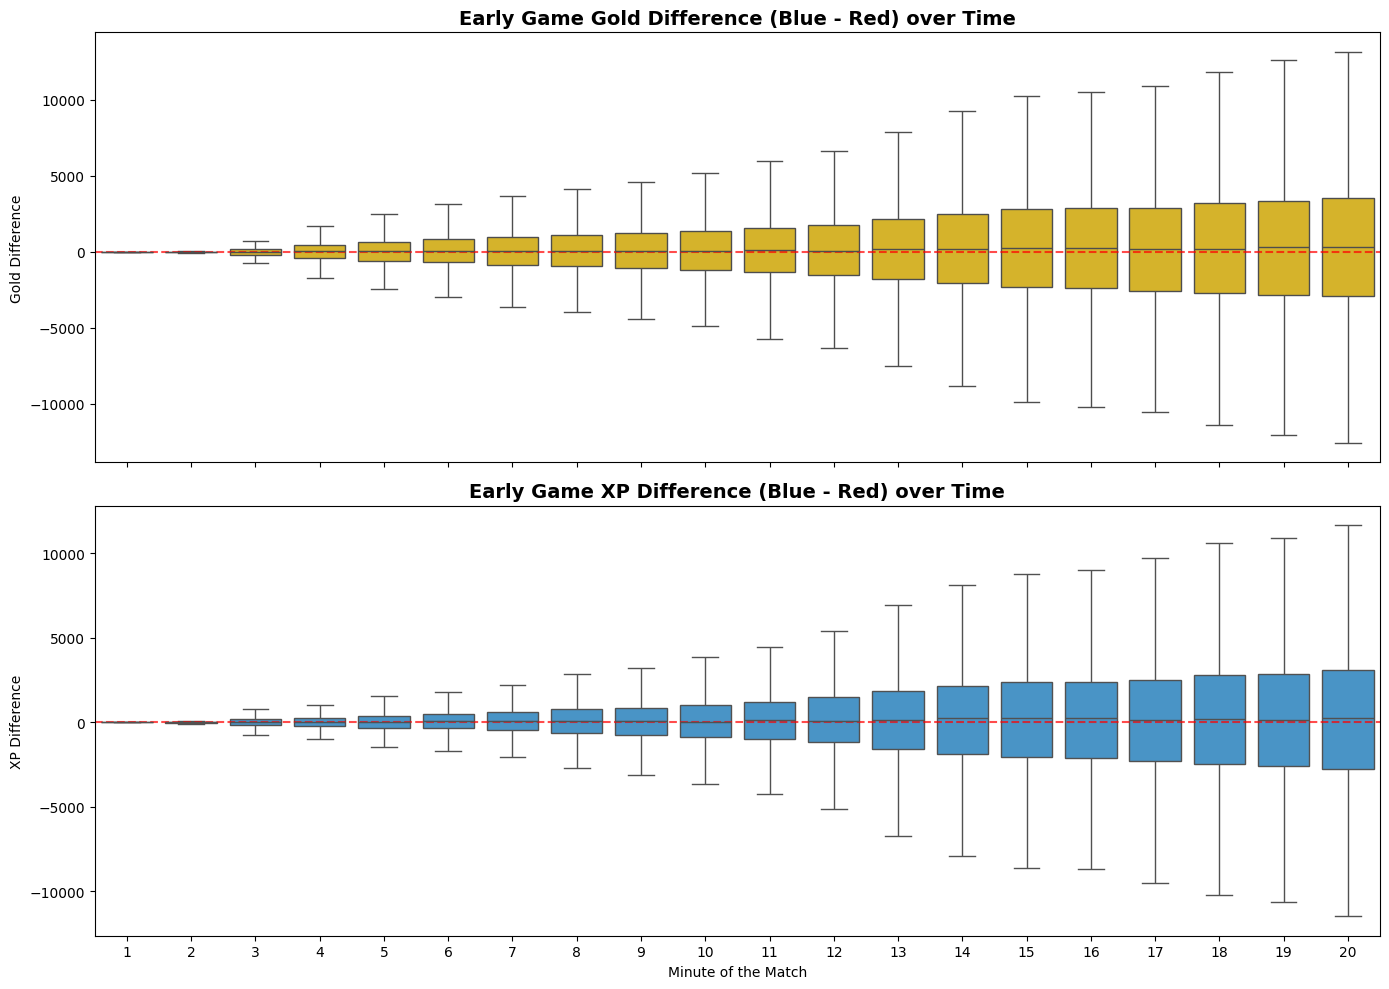

In [21]:
# Filter for the Early/Mid game
early_game_df = eda_df[eda_df['minute'] <= 20]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. Gold Difference Boxplot
sns.boxplot(data=early_game_df, x='minute', y='totalGold_diff', ax=axes[0], color='#f1c40f', showfliers=False)
axes[0].set_title('Early Game Gold Difference (Blue - Red) over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Gold Difference')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)

# 2. XP Difference Boxplot
sns.boxplot(data=early_game_df, x='minute', y='xp_diff', ax=axes[1], color='#3498db', showfliers=False)
axes[1].set_title('Early Game XP Difference (Blue - Red) over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('XP Difference')
axes[1].set_xlabel('Minute of the Match')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Macro & Objective Map with Dynamic Marker Sizes

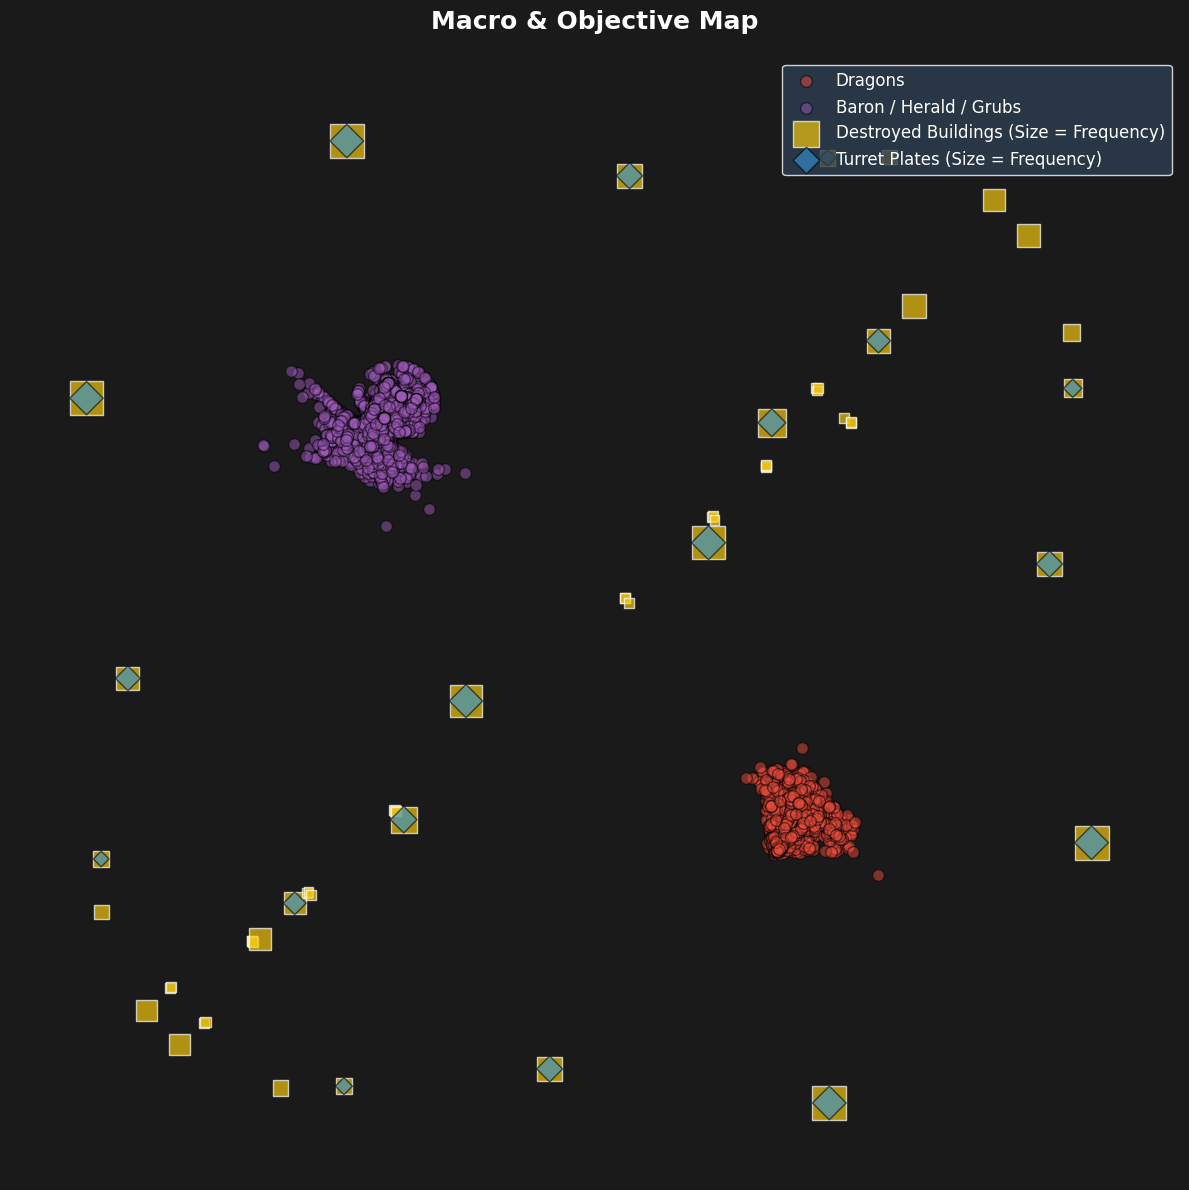

In [26]:
# Filter out all relevant Objective events (where coordinates are available)
objective_types = ['ELITE_MONSTER_KILL', 'BUILDING_KILL', 'TURRET_PLATE_DESTROYED']
macro_df = eda_df[(eda_df['type'].isin(objective_types)) & (eda_df['positionX'].notna())].copy()

# Set the background color for the entire Figure
fig = plt.figure(figsize=(12, 12), facecolor='#1a1a1a')
ax = plt.gca()
ax.set_facecolor('#1a1a1a')

# ELITE MONSTERS
dragons = macro_df[(macro_df['type'] == 'ELITE_MONSTER_KILL') & (macro_df['monsterType'] == 'DRAGON')]
heralds = macro_df[(macro_df['type'] == 'ELITE_MONSTER_KILL') & (macro_df['monsterType'].isin(['RIFTHERALD', 'BARON_NASHOR', 'HORDE']))]

plt.scatter(dragons['positionX'], dragons['positionY'], 
            color='#e74c3c', marker='o', s=70, alpha=0.5, edgecolors='black', label='Dragons')

plt.scatter(heralds['positionX'], heralds['positionY'], 
            color='#9b59b6', marker='o', s=70, alpha=0.5, edgecolors='black', label='Baron / Herald / Grubs')


# Buildings (Frequency-based size)
buildings = macro_df[macro_df['type'] == 'BUILDING_KILL']

# Group by exact coordinates and count occurrences
tower_counts = buildings.groupby(['positionX', 'positionY']).size().reset_index(name='count')

# Calculate dynamic size: Min size 50, Max size 600 based on relative frequency
tower_sizes = 50 + (tower_counts['count'] / tower_counts['count'].max()) * 550

plt.scatter(tower_counts['positionX'], tower_counts['positionY'], 
            color='#f1c40f', marker='s', s=tower_sizes, alpha=0.7, edgecolors='white', 
            label='Destroyed Buildings (Size = Frequency)')


# Turret plates (Frequency-based size)
plates = macro_df[macro_df['type'] == 'TURRET_PLATE_DESTROYED']

# Group by exact coordinates and count occurrences
plate_counts = plates.groupby(['positionX', 'positionY']).size().reset_index(name='count')

# Calculate dynamic size: Min size 20, Max size 300 based on relative frequency
plate_sizes = 20 + (plate_counts['count'] / plate_counts['count'].max()) * 280

plt.scatter(plate_counts['positionX'], plate_counts['positionY'], 
            color='#3498db', marker='D', s=plate_sizes, alpha=0.6, edgecolors='black', 
            label='Turret Plates (Size = Frequency)')


plt.title("Macro & Objective Map", color='white', fontsize=18, fontweight='bold', pad=20)
plt.xlim(0, 15000)
plt.ylim(0, 15000)

# Legend
legend = plt.legend(loc='upper right', fontsize=12, frameon=True, facecolor='#2c3e50', edgecolor='white', labelcolor='white')
legend.get_frame().set_alpha(0.8)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Items with the best winrate & Most frequently used skills

C:\Users\Balázs\AppData\Local\Temp\ipykernel_4984\3643158944.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index.astype(str), ax=axes[0], palette="viridis")
C:\Users\Balázs\AppData\Local\Temp\ipykernel_4984\3643158944.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_counts.index.astype(int).astype(str), y=skill_counts.values, ax=axes[1], palette="magma")


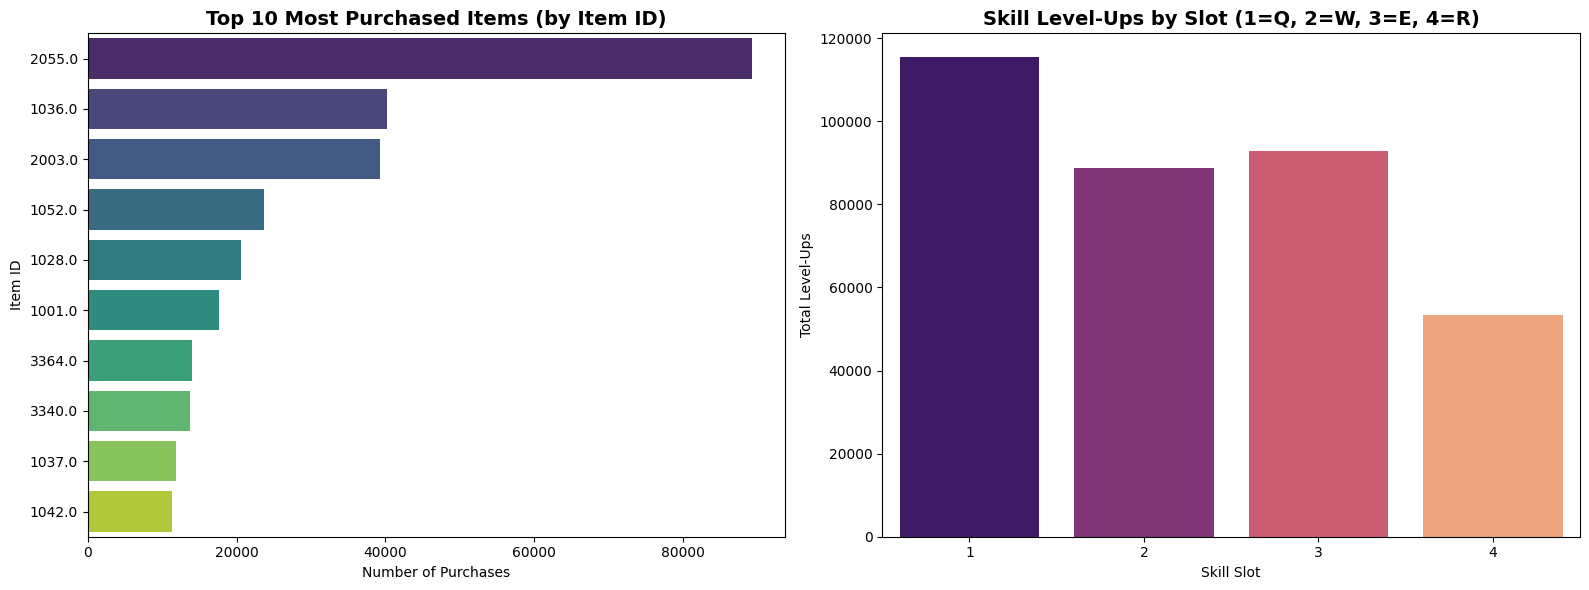

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most commonly purchased items (by item ID)
items_df = eda_df[(eda_df['type'] == 'ITEM_PURCHASED') & (eda_df['itemId'].notna())]
top_items = items_df['itemId'].value_counts().head(10)

sns.barplot(x=top_items.values, y=top_items.index.astype(str), ax=axes[0], palette="viridis")
axes[0].set_title('Top 10 Most Purchased Items (by Item ID)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Item ID')

# Most frequently used skills (by skill slot)
skills_df = eda_df[(eda_df['type'] == 'SKILL_LEVEL_UP') & (eda_df['skillSlot'].notna())]
# Q=1, W=2, E=3, R=4
skill_counts = skills_df['skillSlot'].value_counts().sort_index()

sns.barplot(x=skill_counts.index.astype(int).astype(str), y=skill_counts.values, ax=axes[1], palette="magma")
axes[1].set_title('Skill Level-Ups by Slot (1=Q, 2=W, 3=E, 4=R)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Skill Slot')
axes[1].set_ylabel('Total Level-Ups')

plt.tight_layout()
plt.show()

## Killing Sprees and Multi-Kills Analysis

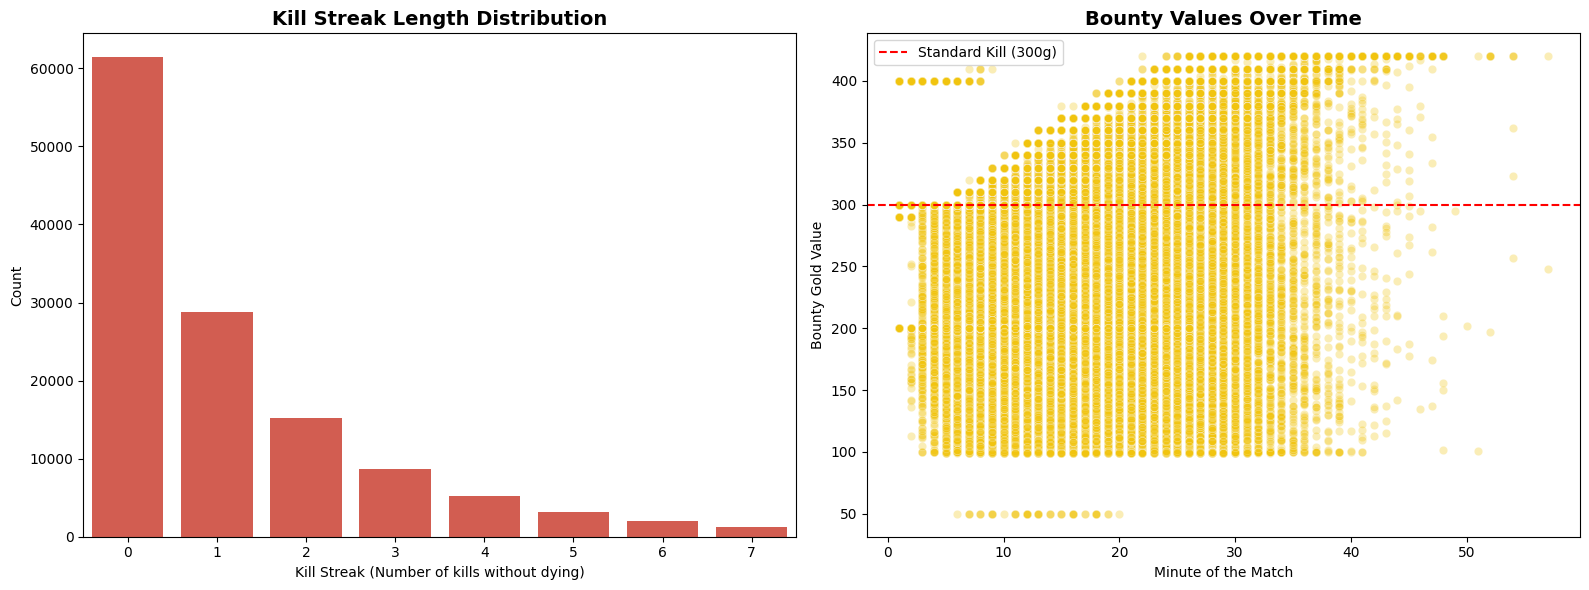

In [6]:
# Filter for champion kills to analyze kill streaks and bounties
kills_df = eda_df[eda_df['type'] == 'CHAMPION_KILL'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kill streak length distribution
if 'killStreakLength' in kills_df.columns:
    streak_counts = kills_df['killStreakLength'].value_counts().sort_index().head(8)
    
    sns.barplot(x=streak_counts.index.astype(int), y=streak_counts.values, ax=axes[0], color='#e74c3c')
    axes[0].set_title('Kill Streak Length Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Kill Streak (Number of kills without dying)')
    axes[0].set_ylabel('Count')

# Bounties over time
if 'bounty' in kills_df.columns:
    sns.scatterplot(data=kills_df, x='minute', y='bounty', ax=axes[1], color='#f1c40f', alpha=0.3)
    axes[1].set_title('Bounty Values Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Minute of the Match')
    axes[1].set_ylabel('Bounty Gold Value')
    
    # 300 gold for a standard kill
    axes[1].axhline(300, color='red', linestyle='--', label='Standard Kill (300g)')
    axes[1].legend()

plt.tight_layout()
plt.show()